In [22]:
# importing modules
import pandas as pd
import numpy as np
import re
import plotnine as p9
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [2]:
# importing data
df = pd.read_csv("./data/musicals_data.csv")

In [3]:
df

,Show,Gross,Avg. Tix,Seats Sold,Total Perf.
0,HAMILTON\n(RICHARD RODGERS),"$128,950,063",$233,"550,747",416
1,WICKED\n(GERSHWIN),"$126,549,673",$157,"805,068",418
2,THE LION KING\n(MINSKOFF),"$106,781,983",$155,"686,358",418
3,HARRY POTTER AND THE CURSED CHILD\n(LYRIC),"$69,332,610",$116,"581,491",415
4,ALADDIN\n(NEW AMSTERDAM),"$68,387,147",$100,"682,435",418
...,...,...,...,...,...
66,SUFFS\n(MUSIC BOX),"$1,349,647",$170,"7,923",8
67,ELF\n(MARQUIS),"$1,214,945",$133,"9,163",7
68,BOOP! THE BETTY BOOP MUSICAL\n(BROADHURST),"$933,732",$72,"13,059",12
69,ROB LAKE MAGIC WITH SPECIAL GUESTS THE MUPPETS...,"$781,726",$39,"20,205",24


In [4]:
# seperating the production's name with the theatre
df[['production', 'theatre']] = df.Show.str.split("\n", expand= True)

In [5]:
#importing list of musicals to make a filter for musicals in my dataset
musicals_0_to_9 = pd.read_csv("./data/List_of_musicals__0_to_9.csv")
musicals_A = pd.read_csv("./data/List_of_musicals__A.csv")
musicals_B = pd.read_csv("./data/List_of_musicals__B.csv")
musicals_C = pd.read_csv("./data/List_of_musicals__C.csv")
musicals_D = pd.read_csv("./data/List_of_musicals__D.csv")
musicals_E = pd.read_csv("./data/List_of_musicals__E.csv")
musicals_F = pd.read_csv("./data/List_of_musicals__F.csv")
musicals_G = pd.read_csv("./data/List_of_musicals__G.csv")
musicals_H = pd.read_csv("./data/List_of_musicals__H.csv")
musicals_I = pd.read_csv("./data/List_of_musicals__I.csv")
musicals_J = pd.read_csv("./data/List_of_musicals__J.csv")
musicals_K = pd.read_csv("./data/List_of_musicals__K.csv")
musicals_L = pd.read_csv("./data/List_of_musicals__L.csv")
musicals_M = pd.read_csv("./data/List_of_musicals__M.csv")
musicals_N = pd.read_csv("./data/List_of_musicals__N.csv")
musicals_O = pd.read_csv("./data/List_of_musicals__O.csv")
musicals_P = pd.read_csv("./data/List_of_musicals__P.csv")
musicals_Q = pd.read_csv("./data/List_of_musicals__Q.csv")
musicals_R = pd.read_csv("./data/List_of_musicals__R.csv")
musicals_S = pd.read_csv("./data/List_of_musicals__S.csv")
musicals_T = pd.read_csv("./data/List_of_musicals__T.csv")
musicals_U = pd.read_csv("./data/List_of_musicals__U.csv")
musicals_V = pd.read_csv("./data/List_of_musicals__V.csv")
musicals_W = pd.read_csv("./data/List_of_musicals__W.csv")
musicals_X = pd.read_csv("./data/List_of_musicals__X.csv")
musicals_Y = pd.read_csv("./data/List_of_musicals__Y.csv")
musicals_Z = pd.read_csv("./data/List_of_musicals__Z.csv")

In [6]:
# combining these lists into one
musicals_list = pd.concat([musicals_0_to_9, musicals_A, musicals_B, musicals_C, musicals_D, musicals_E, musicals_F, musicals_G, musicals_H, musicals_I, musicals_J, musicals_K, musicals_L, musicals_M, musicals_N, musicals_O, musicals_P, musicals_Q, musicals_R, musicals_S, musicals_T, musicals_U, musicals_V, musicals_W, musicals_X, musicals_Y, musicals_Z])

In [7]:
musicals_list

,Production,Year,Venue/type,Music,Lyrics,Book,Notes,Reference
0,8 femmes,2002,French film,Various artists,Various artists,NaN,Based on the 1958 play of the same name by Rob...,NaN
1,9 to 5,2009,Broadway,Dolly Parton,Dolly Parton,Patricia Resnick,Based on the 1980 film.,NaN
2,13\n+ film (2022),2008,Broadway,Jason Robert Brown,Brown,Dan Elish and Robert Horn,The only Broadway musical ever with a cast and...,NaN
3,14-18,2014,Flanders,Dirk Brossé,Allart Blom,NaN,"100 years after World War I, a story of Belgia...",NaN
4,21 Chump Street,2014,Off-Broadway,Lin-Manuel Miranda,Miranda,Miranda,14-minute musical based on a true story told o...,NaN
...,...,...,...,...,...,...,...,...
31,Zombies,2018,Film,George S. Clinton,Clinton,David Light and Joseph Raso,Disney Channel Original Movie,NaN
32,Zombies from The Beyond,1995,Off-Broadway,James Valcq,Valcq,Valcq,NaN,NaN
33,Zorba,1968,Broadway,John Kander,Fred Ebb,Joseph Stein,NaN,NaN
34,Zorro,2008,West End,Gipsy Kings and John Cameron,Stephen Clark,Stephen Clark and Helen Edmundson,NaN,NaN


In [8]:
# creating an series of all the broadway productions
bw_productions = df['production']

In [9]:
# creating a series of all the wiki confirmed musicals so I can use a contains function
wiki_productions = pd.Series(musicals_list['Production'].squeeze())

In [10]:
# creating an empty array for filters to check what productions in df are musicals
confirmed_musicals = np.zeros(71)
# using a for loop to fill out the filters
i = 0
for production in bw_productions:
    if np.any(wiki_productions.str.contains(production, flags=re.IGNORECASE)):
        confirmed_musicals[i] = True
    else:
        confirmed_musicals[i] = False
    i += 1
# transforming into booleans to check
true_check_filter = confirmed_musicals == 1
false_check_filter = confirmed_musicals == 0

/tmp/ipykernel_342/2881572533.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if np.any(wiki_productions.str.contains(production, flags=re.IGNORECASE)):


In [11]:
confirmed_musicals

array([1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
       0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1.,
       0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
       0., 0., 1.])

In [12]:
# performing a manual check that the .contains might have misconfirmed
musicals_manual_check_t = df[true_check_filter]
musicals_manual_check_t
# identified Bug and Art as false positives

,Show,Gross,Avg. Tix,Seats Sold,Total Perf.,production,theatre
0,HAMILTON\n(RICHARD RODGERS),"$128,950,063",$233,"550,747",416,HAMILTON,(RICHARD RODGERS)
1,WICKED\n(GERSHWIN),"$126,549,673",$157,"805,068",418,WICKED,(GERSHWIN)
2,THE LION KING\n(MINSKOFF),"$106,781,983",$155,"686,358",418,THE LION KING,(MINSKOFF)
4,ALADDIN\n(NEW AMSTERDAM),"$68,387,147",$100,"682,435",418,ALADDIN,(NEW AMSTERDAM)
5,MJ\n(NEIL SIMON),"$67,933,749",$131,"515,713",416,MJ,(NEIL SIMON)
6,DEATH BECOMES HER\n(LUNT-FONTANNE),"$66,750,093",$113,"588,352",413,DEATH BECOMES HER,(LUNT-FONTANNE)
7,THE OUTSIDERS\n(JACOBS),"$64,345,030",$153,"419,836",414,THE OUTSIDERS,(JACOBS)
8,MAYBE HAPPY ENDING\n(BELASCO),"$58,544,259",$146,"400,681",416,MAYBE HAPPY ENDING,(BELASCO)
10,THE GREAT GATSBY\n(BROADWAY),"$57,002,764",$103,"549,102",416,THE GREAT GATSBY,(BROADWAY)
12,HELL'S KITCHEN\n(SHUBERT),"$50,368,073",$96,"522,229",416,HELL'S KITCHEN,(SHUBERT)


In [13]:
# performing a manual check of those missed
musicals_manual_check_f = df[false_check_filter]
musicals_manual_check_f
# identified Moulin Rouge, Just in Time, Sunset Boulevard, Six, 
# Cabaret at the Kit Kat Club, Operation Mincemeat, Pirates!, Real Women Have Curves,
# Two Strangers, a Wonderful World, Back to the Future and Boop! as false negatives

,Show,Gross,Avg. Tix,Seats Sold,Total Perf.,production,theatre
3,HARRY POTTER AND THE CURSED CHILD\n(LYRIC),"$69,332,610",$116,"581,491",415,HARRY POTTER AND THE CURSED CHILD,(LYRIC)
9,"OH, MARY!\n(LYCEUM)","$57,916,862",$158,"366,303",416,"OH, MARY!",(LYCEUM)
11,MOULIN ROUGE! THE MUSICAL\n(AL HIRSCHFELD),"$53,973,369",$105,"510,895",416,MOULIN ROUGE! THE MUSICAL,(AL HIRSCHFELD)
13,JUST IN TIME\n(CIRCLE IN THE SQUARE),"$49,394,418",$226,"218,353",309,JUST IN TIME,(CIRCLE IN THE SQUARE)
15,"GOOD NIGHT, AND GOOD LUCK\n(WINTER GARDEN)","$48,276,657",$311,"154,837",99,"GOOD NIGHT, AND GOOD LUCK",(WINTER GARDEN)
17,OTHELLO\n(ETHEL BARRYMORE),"$46,707,510",$377,"123,996",119,OTHELLO,(ETHEL BARRYMORE)
21,STRANGER THINGS: THE FIRST SHADOW\n(MARQUIS),"$40,331,344",$101,"394,390",307,STRANGER THINGS: THE FIRST SHADOW,(MARQUIS)
22,SUNSET BLVD.\n(ST. JAMES),"$38,358,154",$114,"330,110",231,SUNSET BLVD.,(ST. JAMES)
23,SIX: THE MUSICAL\n(LENA HORNE),"$37,631,709",$106,"351,733",415,SIX: THE MUSICAL,(LENA HORNE)
25,GLENGARRY GLEN ROSS\n(PALACE),"$35,845,723",$219,"163,649",127,GLENGARRY GLEN ROSS,(PALACE)


In [14]:
# modifying confirmed filter based on the manual checks
confirmed_musicals[[11, 13, 22, 23, 26, 28, 43, 49, 51, 53, 63, 68]] = True
confirmed_musicals[[29, 70]] = False
# turning the array into a bool
confirmed_musicals = confirmed_musicals == 1

In [15]:
# making the final filtered dataset
df_musicals = df[confirmed_musicals].reset_index(drop=True)
df_musicals

,Show,Gross,Avg. Tix,Seats Sold,Total Perf.,production,theatre
0,HAMILTON\n(RICHARD RODGERS),"$128,950,063",$233,"550,747",416,HAMILTON,(RICHARD RODGERS)
1,WICKED\n(GERSHWIN),"$126,549,673",$157,"805,068",418,WICKED,(GERSHWIN)
2,THE LION KING\n(MINSKOFF),"$106,781,983",$155,"686,358",418,THE LION KING,(MINSKOFF)
3,ALADDIN\n(NEW AMSTERDAM),"$68,387,147",$100,"682,435",418,ALADDIN,(NEW AMSTERDAM)
4,MJ\n(NEIL SIMON),"$67,933,749",$131,"515,713",416,MJ,(NEIL SIMON)
5,DEATH BECOMES HER\n(LUNT-FONTANNE),"$66,750,093",$113,"588,352",413,DEATH BECOMES HER,(LUNT-FONTANNE)
6,THE OUTSIDERS\n(JACOBS),"$64,345,030",$153,"419,836",414,THE OUTSIDERS,(JACOBS)
7,MAYBE HAPPY ENDING\n(BELASCO),"$58,544,259",$146,"400,681",416,MAYBE HAPPY ENDING,(BELASCO)
8,THE GREAT GATSBY\n(BROADWAY),"$57,002,764",$103,"549,102",416,THE GREAT GATSBY,(BROADWAY)
9,MOULIN ROUGE! THE MUSICAL\n(AL HIRSCHFELD),"$53,973,369",$105,"510,895",416,MOULIN ROUGE! THE MUSICAL,(AL HIRSCHFELD)


In [16]:
# turning the relevant data into integers
grosses = pd.Series(df_musicals['Gross'].squeeze())
grosses = grosses.str.replace(",", "")
grosses = grosses.str.strip("$")
grosses = grosses.astype(int)
df_musicals['Gross'] = grosses
seats = pd.Series(df_musicals["Seats Sold"].squeeze())
seats = seats.str.replace(",", "")
seats = seats.astype(int)
df_musicals["Seats Sold"] = seats
tickets = pd.Series(df_musicals["Avg. Tix"].squeeze())
tickets = tickets.str.strip("$")
tickets = tickets.astype(int)
df_musicals["Avg. Tix"] = tickets
df_musicals = df_musicals.rename(columns = {"Gross": "gross ($)", "Avg. Tix": "Avg. Tix ($)"})

In [17]:
# combining the doubled Boop! the Musical data
df_musicals.loc[30, "gross ($)"] = grosses[30] + grosses[40]
df_musicals.loc[30, "Seats Sold"] = seats[30] + seats[40]
boop_ticket = df_musicals.loc[30, "gross ($)"] / df_musicals.loc[30, "Seats Sold"]
df_musicals.loc[30, "Avg. Tix ($)"] = int(boop_ticket)
df_musicals.loc[30, "Total Perf."] = df_musicals.loc[30, "Total Perf."] + df_musicals.loc[40, "Total Perf."]
df_musicals = df_musicals.head(40)
df_musicals

,Show,gross ($),Avg. Tix ($),Seats Sold,Total Perf.,production,theatre
0,HAMILTON\n(RICHARD RODGERS),128950063,233,550747,416,HAMILTON,(RICHARD RODGERS)
1,WICKED\n(GERSHWIN),126549673,157,805068,418,WICKED,(GERSHWIN)
2,THE LION KING\n(MINSKOFF),106781983,155,686358,418,THE LION KING,(MINSKOFF)
3,ALADDIN\n(NEW AMSTERDAM),68387147,100,682435,418,ALADDIN,(NEW AMSTERDAM)
4,MJ\n(NEIL SIMON),67933749,131,515713,416,MJ,(NEIL SIMON)
5,DEATH BECOMES HER\n(LUNT-FONTANNE),66750093,113,588352,413,DEATH BECOMES HER,(LUNT-FONTANNE)
6,THE OUTSIDERS\n(JACOBS),64345030,153,419836,414,THE OUTSIDERS,(JACOBS)
7,MAYBE HAPPY ENDING\n(BELASCO),58544259,146,400681,416,MAYBE HAPPY ENDING,(BELASCO)
8,THE GREAT GATSBY\n(BROADWAY),57002764,103,549102,416,THE GREAT GATSBY,(BROADWAY)
9,MOULIN ROUGE! THE MUSICAL\n(AL HIRSCHFELD),53973369,105,510895,416,MOULIN ROUGE! THE MUSICAL,(AL HIRSCHFELD)


In [18]:
# manually checking for leitmotifs and imputting them
df_musicals["leitmotif"] = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
df_musicals

,Show,gross ($),Avg. Tix ($),Seats Sold,Total Perf.,production,theatre,leitmotif
0,HAMILTON\n(RICHARD RODGERS),128950063,233,550747,416,HAMILTON,(RICHARD RODGERS),1
1,WICKED\n(GERSHWIN),126549673,157,805068,418,WICKED,(GERSHWIN),1
2,THE LION KING\n(MINSKOFF),106781983,155,686358,418,THE LION KING,(MINSKOFF),1
3,ALADDIN\n(NEW AMSTERDAM),68387147,100,682435,418,ALADDIN,(NEW AMSTERDAM),1
4,MJ\n(NEIL SIMON),67933749,131,515713,416,MJ,(NEIL SIMON),1
5,DEATH BECOMES HER\n(LUNT-FONTANNE),66750093,113,588352,413,DEATH BECOMES HER,(LUNT-FONTANNE),1
6,THE OUTSIDERS\n(JACOBS),64345030,153,419836,414,THE OUTSIDERS,(JACOBS),1
7,MAYBE HAPPY ENDING\n(BELASCO),58544259,146,400681,416,MAYBE HAPPY ENDING,(BELASCO),1
8,THE GREAT GATSBY\n(BROADWAY),57002764,103,549102,416,THE GREAT GATSBY,(BROADWAY),1
9,MOULIN ROUGE! THE MUSICAL\n(AL HIRSCHFELD),53973369,105,510895,416,MOULIN ROUGE! THE MUSICAL,(AL HIRSCHFELD),1


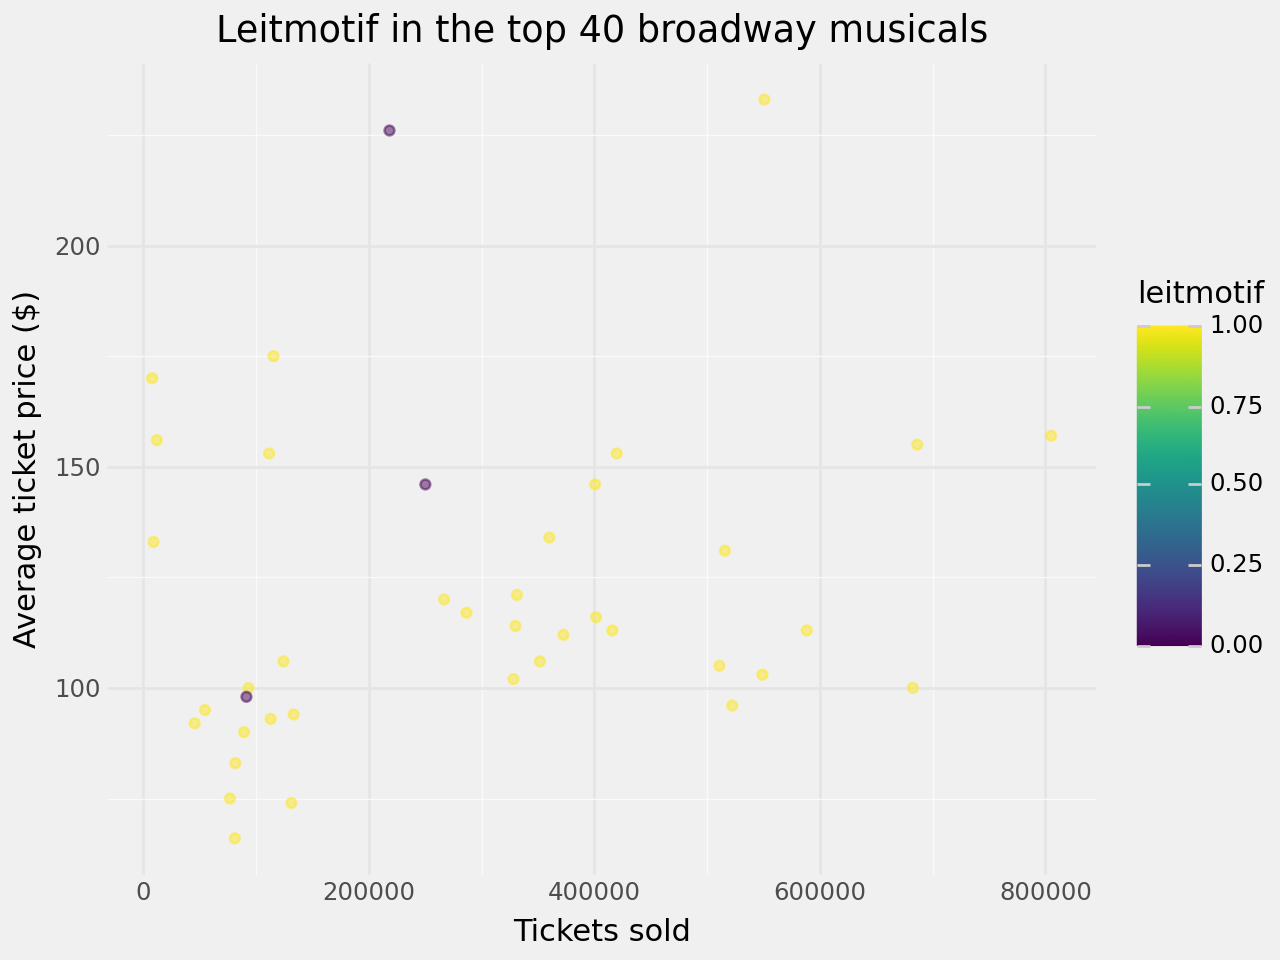

In [27]:
(
    p9.ggplot(df_musicals, p9.aes(x = "Seats Sold", y = "Avg. Tix ($)", colour = "leitmotif")) 
    + p9.geom_point(alpha = 0.5) 
    + p9.labs(title = "Leitmotif in the top 40 broadway musicals", x = "Tickets sold", y = "Average ticket price ($)") 
    + p9.theme_minimal()
)

In [20]:
df_musicals.describe()

,gross ($),Avg. Tix ($),Seats Sold,Total Perf.,leitmotif
count,4.000000e+01,40.000000,40.00000,40.000000,40.000000
mean,3.691466e+07,121.800000,287950.55000,251.600000,0.925000
std,3.253946e+07,36.780848,215499.11886,158.037289,0.266747
min,1.214945e+06,66.000000,7923.00000,7.000000,0.000000
25%,9.179233e+06,97.500000,92856.50000,102.500000,1.000000
50%,3.518525e+07,113.000000,276746.00000,283.500000,1.000000
75%,5.126940e+07,146.000000,416881.00000,416.000000,1.000000
max,1.289501e+08,233.000000,805068.00000,418.000000,1.000000


X = the mean share of total income in the top 40 grossing Broadway musicals in 2025 made by musicals using leitmotif

H0: X <= 0.5

H1: X > 0.5

α = 0.05

In [20]:
# saving the total gross
total_gross = df_musicals["gross ($)"].sum()
print(total_gross)
# saving the real result
real_filter = pd.Series(df_musicals['leitmotif'].squeeze())
real_filter = real_filter.to_numpy()
real_filter = real_filter == 1
real_leitmotif = df_musicals[real_filter]
real_gross = real_leitmotif["gross ($)"].sum()
print(real_gross)
real_share = real_gross/total_gross
print(real_share)

1476586464
1382056407
0.935980682943603


In [21]:
# creating arrays for the permutation test and my permuted results
fake_filter = np.zeros(40)
permutations = np.zeros(100000)
# setting the seed so my results are reproducable
np.random.seed(13)
# filling the array with permutations
for permutation in range(100000):
    for musical in range(40):
        random = np.random.choice([0, 1])
        fake_filter[musical] = random
    fake_filter = fake_filter == 1
    fake_leitmotif = df_musicals[fake_filter]
    fake_gross = fake_leitmotif["gross ($)"].sum()
    fake_share = fake_gross/total_gross
    permutations[permutation] = fake_share

In [22]:
# getting descriptive statistics of the permutations
permutations_df = pd.DataFrame(permutations)
permutations_df.describe()

,0
count,100000.000000
mean,0.499524
std,0.104878
min,0.110356
25%,0.426875
50%,0.499725
75%,0.571937
max,0.905311


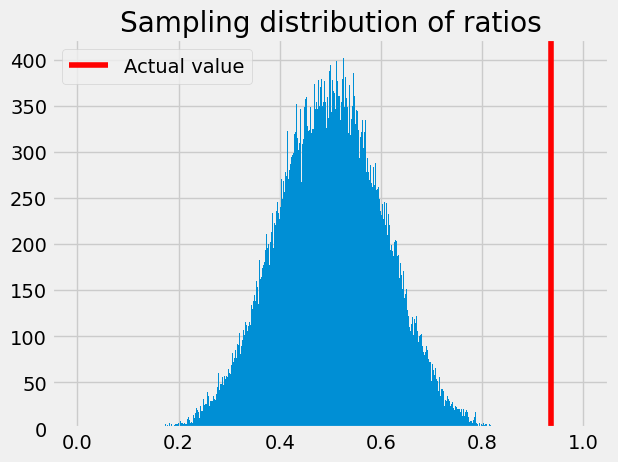

In [23]:
# plotting all the permutations on a histogram
plt.hist(permutations, bins=1000, range=(0,1))
plt.title('Sampling distribution of ratios')
# Showing the position of the actual value on the x-axis.
plt.axvline(real_share, color='red', label='Actual value')
# Labeling the actual value line.
plt.legend();

In [24]:
# using the permutations to get a p-value
p_value = np.count_nonzero((permutations>=real_ratio)/100000)
p_value
# a p-value of 0 with 100,000 permutations

np.int64(0)